
#### [ LinearRegression - 숫자값 예측 학습 모델 ]

- **선형회귀** 
    * 피쳐와 타겟 사이에 선형 관계가 있다고 가정
    * 그 관계를 가장 잘 설명하는 직선 또는 선형식을 학습하는 회귀 모델
    * 모델링 전 ==> 산점도, 상관계수, 잔차 분석 등을 통해 선형성 확인 필요

- **포함내용**
    1. 단순선형회귀
    2. 다중선형회귀
    3. 다항선형회귀

- **데이터셋** 
    - 사용 파일: housing.csv
    - 타겟 컬럼: MEDV - 주택 가격 중앙값
    - 원본 CSV에는 컬럼명이 없으므로 코드에서 컬럼명을 직접 지정


##### **[0] 모듈 로딩 -----**

In [16]:
## 데이터 처리 관련 모듈
import pandas as pd
import numpy as np

## 시각화 관련 모듈
import matplotlib.pyplot as plt

## 데이터 분리 관련 모듈
from sklearn.model_selection import train_test_split

## ML 모델 관련 모듈
from sklearn.linear_model import LinearRegression

## ML 전처리 모듈
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

## ML 자동화 관련 모듈
from sklearn.pipeline import Pipeline

## 평가 지표 관련 모듈
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


##### **[1]데이터 준비 및 로딩 -----**

In [17]:
## => 데이터 파일
DATA_FILE = '../Data/Numbers/housing.csv'
NAME_FILE = '../Data/Numbers/housing_title_column.txt'


## => 데이터 & 컬러명 로딩 : 첫번째 줄 컬럼명 X, 데이터 사이 공백 여러개
## - header = None
## - sep    = r'\s+'      \s : whitespace 표현식, + : 1개 이상
## - names  = housing_title_column.txt에서 지정 
with open(NAME_FILE, mode='r') as F:
    lines = F.readlines()

column_names = [ line.split(' - ')[0] for line in lines ]
df = pd.read_csv(DATA_FILE, sep=r"\s+", header=None, names=column_names )

## 데이터 앞부분 확인
display(df.head())

## 데이터 크기 확인
print("데이터 크기:", df.shape)

## 컬럼명 확인
print("컬럼명:", df.columns.tolist())


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


데이터 크기: (506, 14)
컬럼명: ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


In [18]:
## =========================================================
## 3. 데이터 기본 정보 확인
## =========================================================

## 데이터 타입과 결측치 개수 확인
df.info()

## 수치형 통계량 확인
display(df.describe())

## 결측치 개수 확인
print("결측치 개수:")
print(df.isna().sum())


## 컬럼별 고유값 확인
value_counts = { col: len(df[col].value_counts()) for col in df.columns }
print(sorted(value_counts.items(), key=lambda x:x[1]))

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


결측치 개수:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64
[('CHAS', 2), ('RAD', 9), ('ZN', 26), ('PTRATIO', 46), ('TAX', 66), ('INDUS', 76), ('NOX', 81), ('MEDV', 229), ('AGE', 356), ('B', 357), ('DIS', 412), ('RM', 446), ('LSTAT', 455), ('CRIM', 504)]


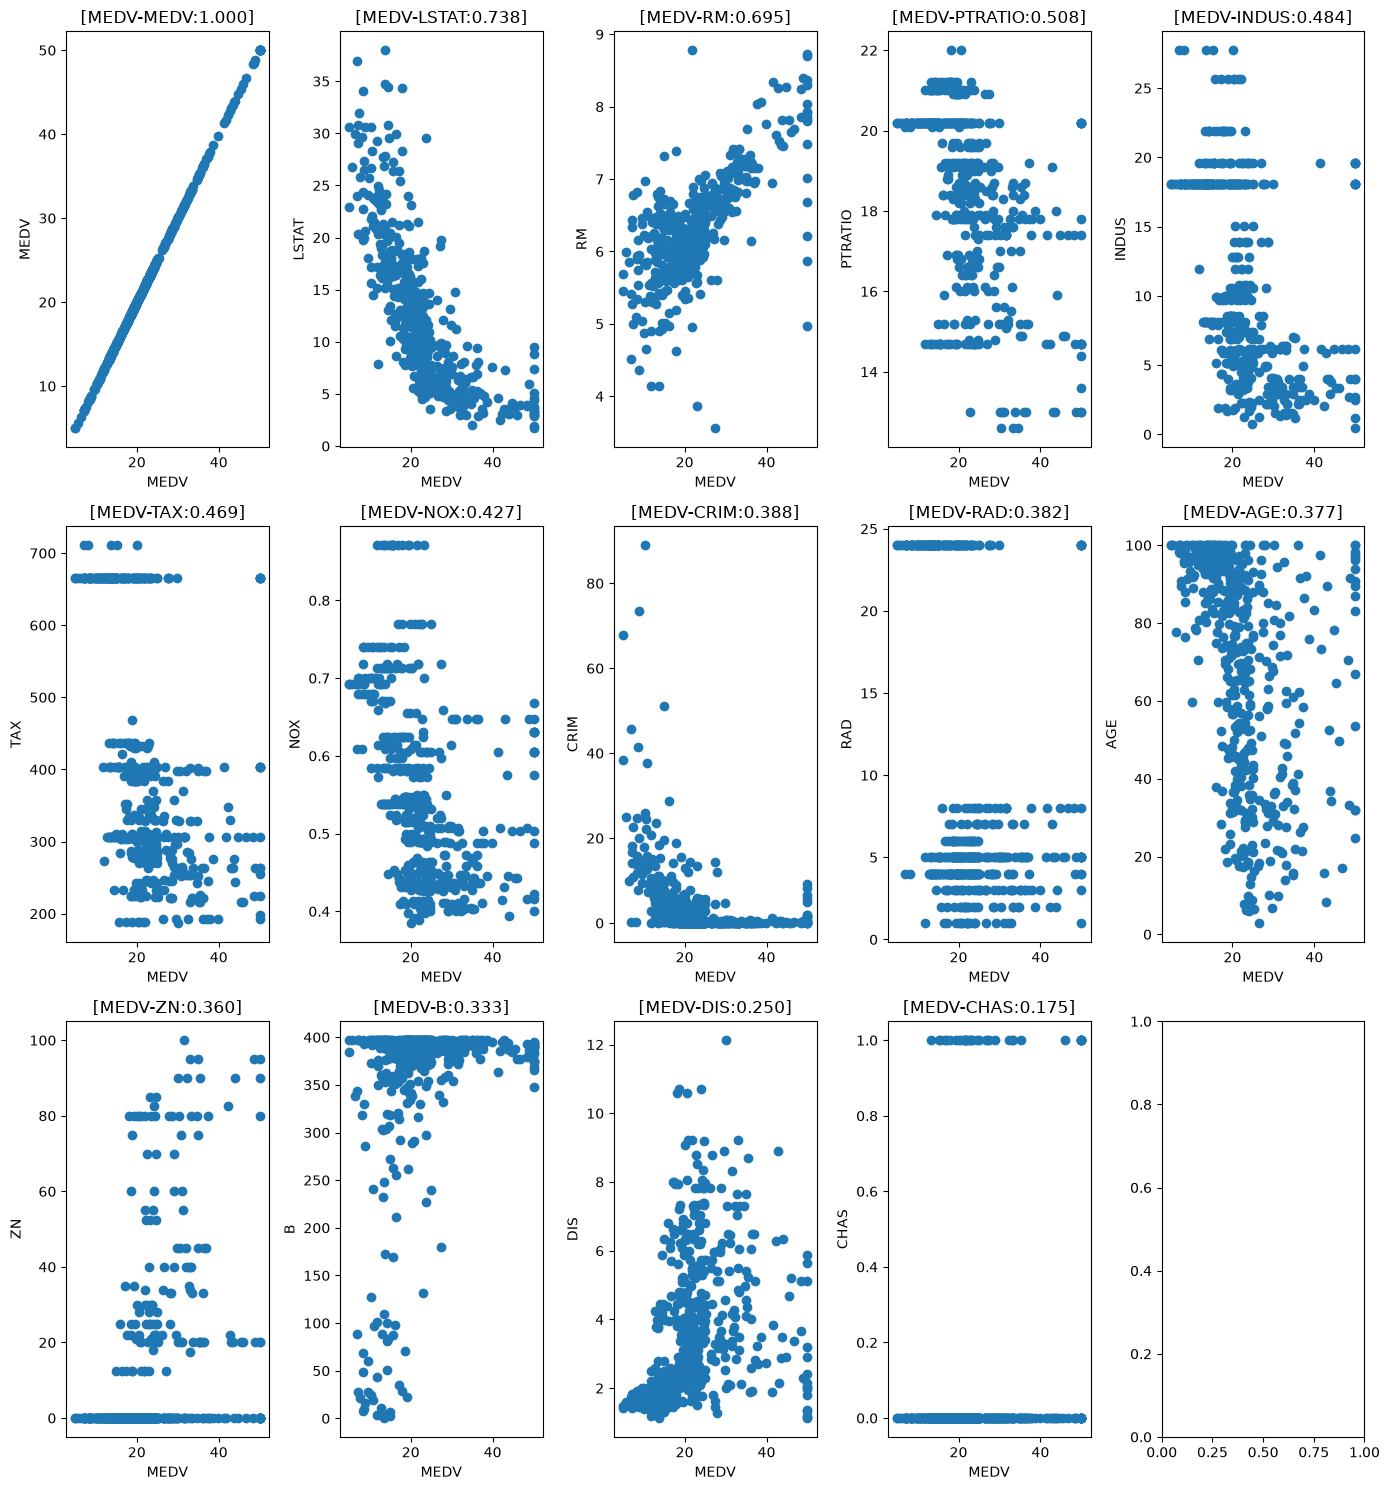

In [19]:
## 상관계수 확인
corrSR = df.corr()['MEDV'].abs().sort_values(ascending=False)

fig, axes = plt.subplots(3,5, figsize=(14, 15))
axes = axes.flatten()

for ax, col in zip(axes, corrSR.index):
    ax.scatter(df['MEDV'], df[col])
    ax.set_title(f'[MEDV-{col}:{corrSR[col]:.3f}]')
    ax.set_xlabel('MEDV')
    ax.set_ylabel(f'{col}')

plt.tight_layout()
plt.show()

In [21]:

## =========================================================
## 4. 공통 평가 함수 생성
## =========================================================

def regression_evaluation(y_true, y_pred, model_name="model"):
    ## 실제값과 예측값을 받아 회귀 평가 지표 출력
    ## MSE  : 오차 제곱 평균
    ## RMSE : MSE의 제곱근
    ## MAE  : 오차 절댓값 평균
    ## R2   : 설명력, 1에 가까울수록 좋음

    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)

    return { "model": model_name, "MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2 }



# 1. 단순선형회귀

단순선형회귀는 피쳐 1개로 타겟을 예측하는 회귀 모델이다.

여기서는 `RM` 컬럼 하나로 `MEDV`를 예측한다.

- `RM`: 주택 1채당 평균 방 개수
- `MEDV`: 주택 가격 중앙값


In [22]:

## =========================================================
## 5. 단순선형회귀 데이터 준비
## =========================================================

## 단순선형회귀에서는 피쳐 1개만 사용
## RM 컬럼은 평균 방 개수를 의미
X_simple = df[["RM"]]

## 타겟 컬럼
y = df["MEDV"]

## 훈련 데이터와 테스트 데이터 분리
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train_s 크기:", X_train_s.shape)
print("X_test_s 크기 :", X_test_s.shape)


X_train_s 크기: (404, 1)
X_test_s 크기 : (102, 1)


In [23]:
## =========================================================
## 6. 단순선형회귀 모델 학습
## =========================================================

## LinearRegression 모델 생성
simple_model = LinearRegression()

## 모델 학습
simple_model.fit(X_train_s, y_train_s)

## 테스트 데이터 예측
y_pred_s = simple_model.predict(X_test_s)

## 회귀 계수와 절편 확인
print("기울기 coef_:", simple_model.coef_)
print("절편 intercept_:", simple_model.intercept_)

## 평가
result_simple = regression_evaluation( y_test_s, y_pred_s, model_name="Simple Linear Regression" )


기울기 coef_: [9.34830141]
절편 intercept_: -36.24631889813795
Simple Linear Regression
MSE : 46.144775347317264
RMSE: 6.792994578778734
MAE : 4.478335832064149
R2  : 0.3707569232254778


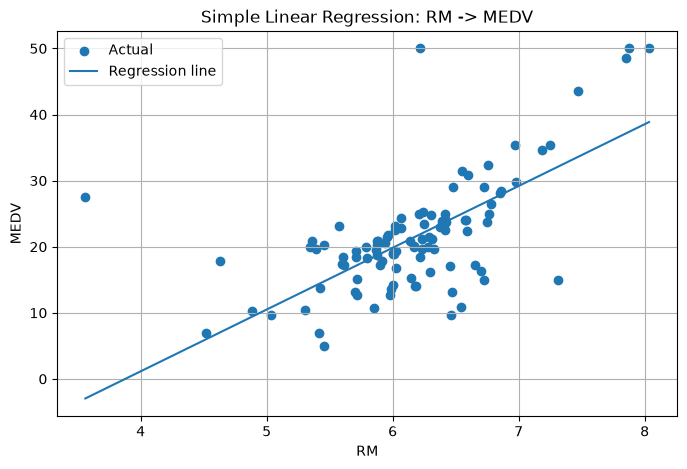

In [24]:

## =========================================================
## 7. 단순선형회귀 시각화
## =========================================================

## 산점도와 회귀선 시각화
plt.figure(figsize=(8, 5))

## 실제 데이터 산점도
plt.scatter(X_test_s["RM"], y_test_s, label="Actual")

## 회귀선 표시를 위해 RM 값을 정렬
sort_idx = np.argsort(X_test_s["RM"].values)
x_sorted = X_test_s["RM"].values[sort_idx]
y_pred_sorted = y_pred_s[sort_idx]

## 예측 회귀선
plt.plot(x_sorted, y_pred_sorted, label="Regression line")

plt.xlabel("RM")
plt.ylabel("MEDV")
plt.title("Simple Linear Regression: RM -> MEDV")
plt.legend()
plt.grid(True)
plt.show()



# 2. 다중선형회귀

다중선형회귀는 여러 개의 피쳐로 하나의 타겟을 예측하는 회귀 모델이다.

여기서는 `MEDV`를 제외한 모든 컬럼을 피쳐로 사용한다.


In [25]:

## =========================================================
## 8. 다중선형회귀 데이터 준비
## =========================================================

## MEDV를 제외한 모든 컬럼을 피쳐로 사용
X_multi = df.drop("MEDV", axis=1)

## 타겟 컬럼
y = df["MEDV"]

## 훈련 데이터와 테스트 데이터 분리
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train_m 크기:", X_train_m.shape)
print("X_test_m 크기 :", X_test_m.shape)


X_train_m 크기: (404, 13)
X_test_m 크기 : (102, 13)


In [26]:

## =========================================================
## 9. 다중선형회귀 모델 학습
## =========================================================

## LinearRegression 모델 생성
multi_model = LinearRegression()

## 모델 학습
multi_model.fit(X_train_m, y_train_m)

## 테스트 데이터 예측
y_pred_m = multi_model.predict(X_test_m)

## 평가
result_multi = regression_evaluation(
    y_test_m,
    y_pred_m,
    model_name="Multiple Linear Regression"
)


Multiple Linear Regression
MSE : 24.291119474973357
RMSE: 4.92860218266532
MAE : 3.1890919658878296
R2  : 0.6687594935356342


In [27]:

## =========================================================
## 10. 다중선형회귀 회귀 계수 확인
## =========================================================

## 각 피쳐별 회귀 계수를 DataFrame으로 정리
coef_df = pd.DataFrame({
    "feature": X_multi.columns,
    "coefficient": multi_model.coef_
})

## 계수 절댓값 기준으로 정렬
coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

display(coef_df)


,feature,coefficient,abs_coefficient
4,NOX,-17.202633,17.202633
5,RM,4.438835,4.438835
3,CHAS,2.784438,2.784438
7,DIS,-1.447865,1.447865
10,PTRATIO,-0.915456,0.915456
12,LSTAT,-0.508571,0.508571
8,RAD,0.262430,0.262430
0,CRIM,-0.113056,0.113056
2,INDUS,0.040381,0.040381
1,ZN,0.030110,0.030110


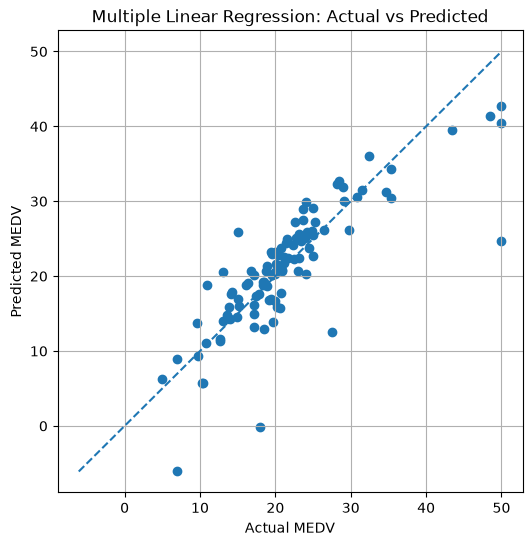

In [28]:

## =========================================================
## 11. 다중선형회귀 실제값과 예측값 비교 시각화
## =========================================================

plt.figure(figsize=(6, 6))

## 실제값과 예측값 산점도
plt.scatter(y_test_m, y_pred_m)

## 기준선 표시
min_value = min(y_test_m.min(), y_pred_m.min())
max_value = max(y_test_m.max(), y_pred_m.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Multiple Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.show()



# 3. 다항선형회귀

다항선형회귀는 원본 피쳐를 제곱항, 교차항 등으로 확장한 뒤 선형회귀를 적용하는 방식이다.

모델 자체는 `LinearRegression`이지만, 입력 피쳐가 다항식 형태로 변환된다.

예:

```text
RM, LSTAT
→ RM, LSTAT, RM^2, RM*LSTAT, LSTAT^2
```


In [29]:

## =========================================================
## 12. 다항선형회귀 데이터 준비
## =========================================================

## 다항선형회귀 예제에서는 해석과 시각화를 쉽게 하기 위해 피쳐 2개 사용
## RM    : 평균 방 개수
## LSTAT : 저소득층 비율
X_poly_base = df[["RM", "LSTAT"]]

## 타겟 컬럼
y = df["MEDV"]

## 훈련 데이터와 테스트 데이터 분리
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly_base,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train_p 크기:", X_train_p.shape)
print("X_test_p 크기 :", X_test_p.shape)


X_train_p 크기: (404, 2)
X_test_p 크기 : (102, 2)


In [30]:

## =========================================================
## 13. 다항선형회귀 Pipeline 생성 및 학습
## =========================================================

## PolynomialFeatures로 다항 피쳐 생성
## degree=2는 2차항까지 생성
## include_bias=False는 상수항 컬럼을 만들지 않도록 설정
##
## StandardScaler는 다항 피쳐의 값 범위 차이를 줄이기 위해 사용
## LinearRegression은 변환된 다항 피쳐로 회귀 학습

poly_model = Pipeline(steps=[
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("linear", LinearRegression())
])

## 모델 학습
poly_model.fit(X_train_p, y_train_p)

## 테스트 데이터 예측
y_pred_p = poly_model.predict(X_test_p)

## 평가
result_poly = regression_evaluation(
    y_test_p,
    y_pred_p,
    model_name="Polynomial Linear Regression degree=2"
)


Polynomial Linear Regression degree=2
MSE : 18.433777739111076
RMSE: 4.293457550635743
MAE : 2.8833469473605358
R2  : 0.7486318454509433


In [31]:

## =========================================================
## 14. 생성된 다항 피쳐 이름 확인
## =========================================================

## Pipeline 안의 PolynomialFeatures 단계 꺼내기
poly_step = poly_model.named_steps["poly"]

## 생성된 피쳐 이름 확인
poly_feature_names = poly_step.get_feature_names_out(X_poly_base.columns)

print("생성된 다항 피쳐:")
print(poly_feature_names)


생성된 다항 피쳐:
['RM' 'LSTAT' 'RM^2' 'RM LSTAT' 'LSTAT^2']


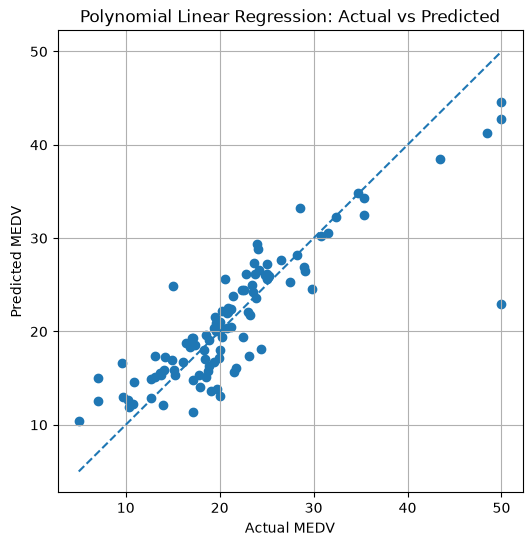

In [32]:

## =========================================================
## 15. 다항선형회귀 실제값과 예측값 비교 시각화
## =========================================================

plt.figure(figsize=(6, 6))

## 실제값과 예측값 산점도
plt.scatter(y_test_p, y_pred_p)

## 기준선 표시
min_value = min(y_test_p.min(), y_pred_p.min())
max_value = max(y_test_p.max(), y_pred_p.max())
plt.plot([min_value, max_value], [min_value, max_value], linestyle="--")

plt.xlabel("Actual MEDV")
plt.ylabel("Predicted MEDV")
plt.title("Polynomial Linear Regression: Actual vs Predicted")
plt.grid(True)
plt.show()


,model,MSE,RMSE,MAE,R2
0,Simple Linear Regression,46.144775,6.792995,4.478336,0.370757
1,Multiple Linear Regression,24.291119,4.928602,3.189092,0.668759
2,Polynomial Linear Regression degree=2,18.433778,4.293458,2.883347,0.748632


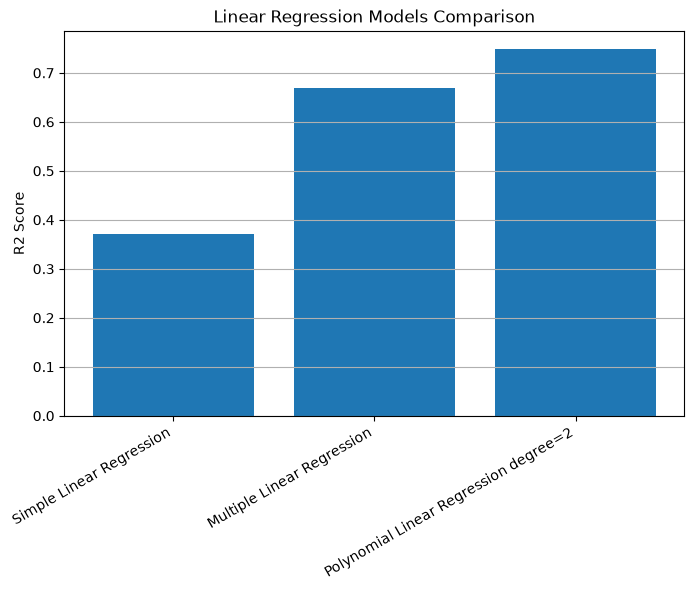

In [33]:

## =========================================================
## 16. 세 모델 평가 결과 비교
## =========================================================

## 평가 결과를 DataFrame으로 정리
result_df = pd.DataFrame([
    result_simple,
    result_multi,
    result_poly
])

display(result_df)

## R2 기준 시각화
plt.figure(figsize=(8, 5))
plt.bar(result_df["model"], result_df["R2"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("R2 Score")
plt.title("Linear Regression Models Comparison")
plt.grid(axis="y")
plt.show()



## 최종 정리

| 모델 | 특징 |
|---|---|
| 단순선형회귀 | 피쳐 1개로 타겟 예측 |
| 다중선형회귀 | 여러 피쳐로 타겟 예측 |
| 다항선형회귀 | 피쳐를 제곱항, 교차항 등으로 확장 후 선형회귀 적용 |

다항선형회귀는 이름에 선형회귀가 들어가지만, 원본 피쳐 관점에서는 곡선 관계를 표현할 수 있다.
